## Aprendizado por reforço

Imagine o labirinto abaixo:

[$\mathrm{Buraco}$] [$\qquad$] [$\qquad$] [$\qquad$] [$\qquad$]  [ $\mathrm{Partida}$ ] [$\qquad$] [$\qquad$] [$\qquad$] [ $\mathrm{Chegada}$ ]

O agente, que inicia sua trajetória na casa "Partida", por escolher entre duas ações:
- $-1$: andar para trás;
- $+1$: andar para frente.

Cada vez que ele realiza uma ação, o agente recebe uma recompensa ou uma punição de +1 e -1 ponto respectivamente. Ao atingir as posições +10 ou -10 o jogo se encerra.

In [ ]:
import numpy as np

# Definição do ambiente
state = 0          # Posição inicial ("Partida")
actions = [-1, 1]   # Andar para trás ou para frente
limite = +4         # O jogo termina em +3 ou -3
max_steps = 100    # Limite de segurança para não rodar para sempre

recompensa_total = 0
step = 0

# Interação do agente com o ambiente
while abs(state) < limite and step < max_steps:
    action = np.random.choice(actions)  # Escolha aleatória
    state += action

    reward = 1 if action == 1 else -1
    recompensa_total += reward

    step += 1
    print(f"Passo {step}: Ação: {action}, Estado: {state}, Recompensa: {recompensa_total}.")

print(f"\nJogo encerrado no passo {step}, Estado final: {state}, Recompensa total: {recompensa_total}.")

Passo 1: Ação: 1, Estado: 1, Recompensa: 1.
Passo 2: Ação: 1, Estado: 2, Recompensa: 2.
Passo 3: Ação: 1, Estado: 3, Recompensa: 3.
Passo 4: Ação: -1, Estado: 2, Recompensa: 2.
Passo 5: Ação: -1, Estado: 1, Recompensa: 1.
Passo 6: Ação: -1, Estado: 0, Recompensa: 0.
Passo 7: Ação: -1, Estado: -1, Recompensa: -1.
Passo 8: Ação: 1, Estado: 0, Recompensa: 0.
Passo 9: Ação: 1, Estado: 1, Recompensa: 1.
Passo 10: Ação: -1, Estado: 0, Recompensa: 0.
Passo 11: Ação: 1, Estado: 1, Recompensa: 1.
Passo 12: Ação: -1, Estado: 0, Recompensa: 0.
Passo 13: Ação: -1, Estado: -1, Recompensa: -1.
Passo 14: Ação: -1, Estado: -2, Recompensa: -2.
Passo 15: Ação: 1, Estado: -1, Recompensa: -1.
Passo 16: Ação: -1, Estado: -2, Recompensa: -2.
Passo 17: Ação: 1, Estado: -1, Recompensa: -1.
Passo 18: Ação: 1, Estado: 0, Recompensa: 0.
Passo 19: Ação: -1, Estado: -1, Recompensa: -1.
Passo 20: Ação: 1, Estado: 0, Recompensa: 0.
Passo 21: Ação: -1, Estado: -1, Recompensa: -1.
Passo 22: Ação: 1, Estado: 0, Recompe

___
___
___

##Q-Learning

Vamos otimizar o funcionamento do agente por meio do algoritmo Q-learning. Vamos utilizar o mesmo problema do labirinto unidimensional.

Treinamento concluído!

 Estado |    Q(-1) |    Q(+1) | Melhor ação
---------------------------------------------
    -10 |    0.000 |    0.000 | ← trás
     -9 |   -0.410 |    0.681 | → frente
     -8 |   -0.469 |    1.511 | → frente
     -7 |   -0.189 |    2.185 | → frente
     -6 |    0.272 |    2.870 | → frente
     -5 |    0.506 |    5.067 | → frente
     -4 |    2.335 |    6.574 | → frente
     -3 |    4.066 |    6.975 | → frente
     -2 |    4.811 |    7.148 | → frente
     -1 |    5.376 |    6.862 | → frente
      0 |    5.176 |    6.513 | → frente
      1 |    4.862 |    6.126 | → frente
      2 |    4.513 |    5.695 | → frente
      3 |    4.126 |    5.217 | → frente
      4 |    3.695 |    4.686 | → frente
      5 |    3.217 |    4.095 | → frente
      6 |    2.686 |    3.439 | → frente
      7 |    2.095 |    2.710 | → frente
      8 |    1.439 |    1.900 | → frente
      9 |    0.710 |    1.000 | → frente
     10 |    0.000 |    0.000 | ← trás


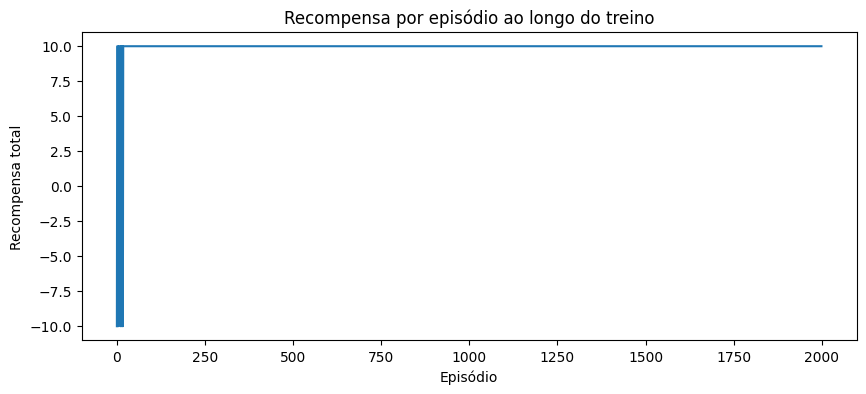


Trajetória final (política aprendida): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Ambiente ---
limite = 10
estados = list(range(-limite, limite + 1))  # posições de -10 a +10
actions = [-1, 1]                            # andar para trás ou para frente
n_states = len(estados)
n_actions = len(actions)

def state_to_index(state):
    return state + limite

# --- Q-table ---
Q = np.zeros((n_states, n_actions))

# --- Hiperparâmetros ---
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
n_episodes = 2000
max_steps_per_episode = 200

recompensas_por_episodio = []

# --- Loop de treinamento ---
for episode in range(n_episodes):
    state = 0
    done = False
    steps = 0
    recompensa_total = 0

    while not done and steps < max_steps_per_episode:
        state_idx = state_to_index(state)

        # Política epsilon-greedy
        if np.random.rand() < epsilon:
            action_idx = np.random.choice(n_actions)
        else:
            action_idx = np.argmax(Q[state_idx])

        action = actions[action_idx]
        next_state = state + action
        reward = 1 if action == 1 else -1
        done = abs(next_state) == limite
        next_state_idx = state_to_index(next_state)

        # Atualização Q-learning
        best_next_q = 0 if done else np.max(Q[next_state_idx])
        Q[state_idx, action_idx] += alpha * (
            reward + gamma * best_next_q - Q[state_idx, action_idx]
        )

        state = next_state
        recompensa_total += reward
        steps += 1

    recompensas_por_episodio.append(recompensa_total)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Treinamento concluído!\n")

# --- Q-table final ---
print(f"{'Estado':>7} | {'Q(-1)':>8} | {'Q(+1)':>8} | Melhor ação")
print("-" * 45)
for s in estados:
    idx = state_to_index(s)
    q_esq, q_dir = Q[idx]
    melhor = "→ frente" if q_dir > q_esq else "← trás"
    print(f"{s:>7} | {q_esq:>8.3f} | {q_dir:>8.3f} | {melhor}")

# --- Gráfico da recompensa por episódio ---
plt.figure(figsize=(10, 4))
plt.plot(recompensas_por_episodio)
plt.xlabel("Episódio")
plt.ylabel("Recompensa total")
plt.title("Recompensa por episódio ao longo do treino")
plt.show()

# --- Testando a política aprendida (sem exploração) ---
state = 0
trajetoria = [state]
steps = 0
while abs(state) < limite and steps < max_steps_per_episode:
    state_idx = state_to_index(state)
    action_idx = np.argmax(Q[state_idx])
    action = actions[action_idx]
    state += action
    trajetoria.append(state)
    steps += 1

print(f"\nTrajetória final (política aprendida): {trajetoria}")